In [ ]:
# Run this line to install the acc_sync package
!git clone https://github.com/tomxi/acc_sync.git
%cd acc_sync
!pip install . -e

In [ ]:
from acc_sync import util, viz

import matplotlib.pyplot as plt
import numpy as np
import librosa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1: Load data, view dataframe, and plot

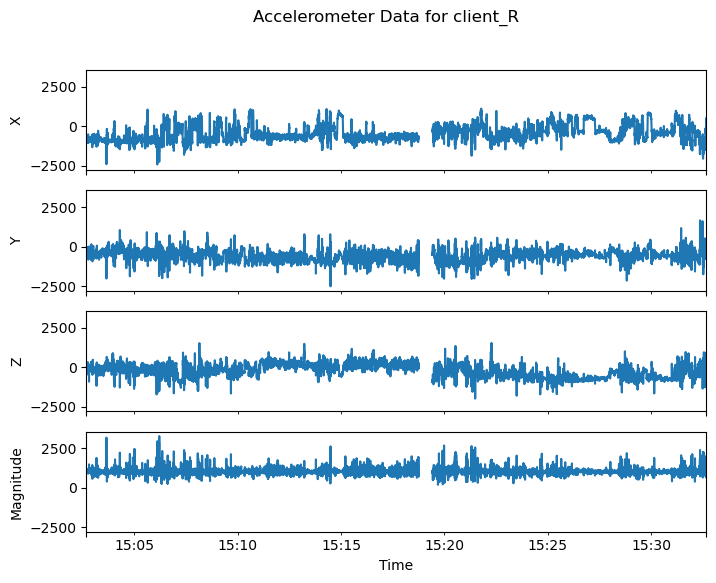

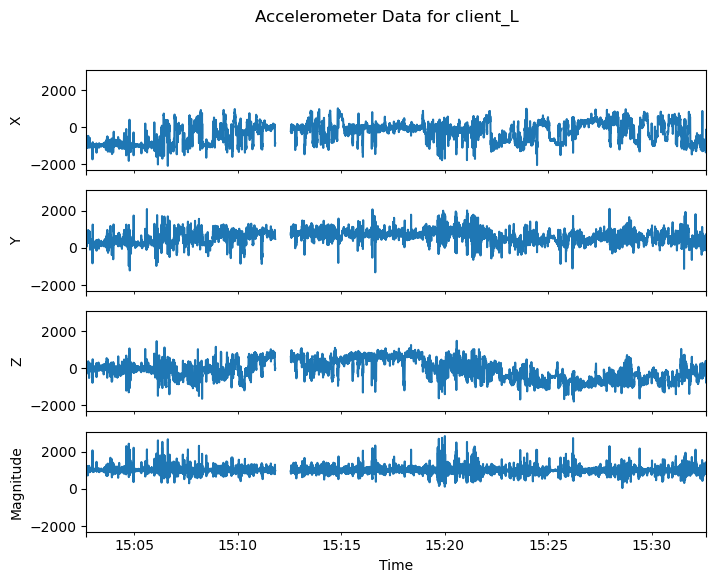

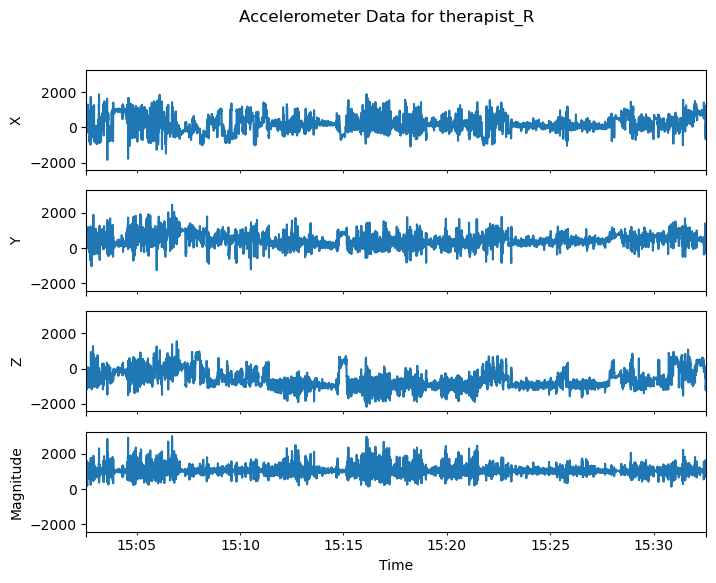

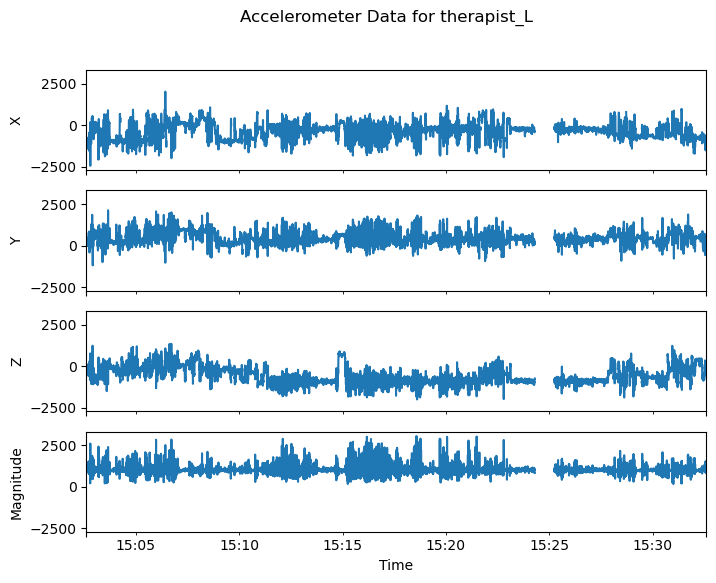

In [141]:
session = util.load_session_data(
    pt="RF001",
    session="2025_11_15",
    roles=["client", "therapist"],
    hands=["R", "L"]
)

for wearable in session:
    fig = viz.plot_acc(session[wearable])
    fig.suptitle(f"Accelerometer Data for {wearable}")
    plt.show()

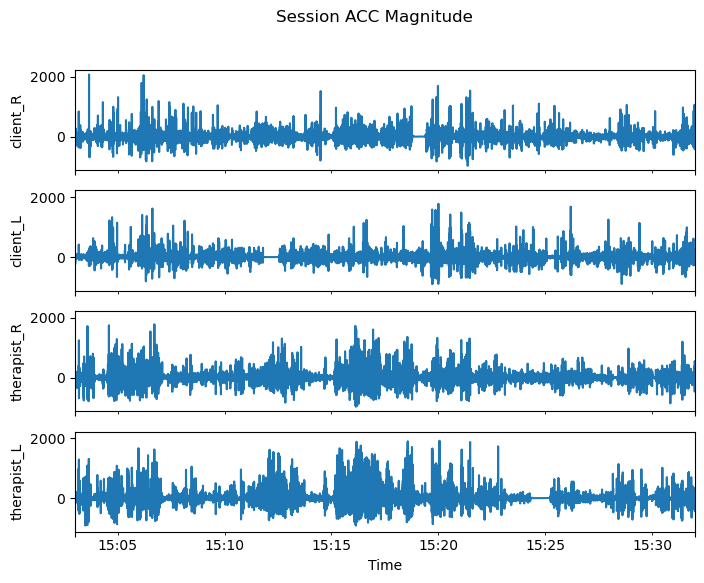

In [142]:
# We trim the session to the time of interest, fill missing values, and filter with a 10 Hz lowpass and 0.1 Hz highpass filter
acc_mag = util.prep_session_mag(session, start_time='15:03:00', end_time='15:32:00')
fig = viz.plot_mag_dict(acc_mag, figsize=(8, 6))
plt.show()

# 2: Time domain analysis of synchrony via Time-Lag Cross-Correlation

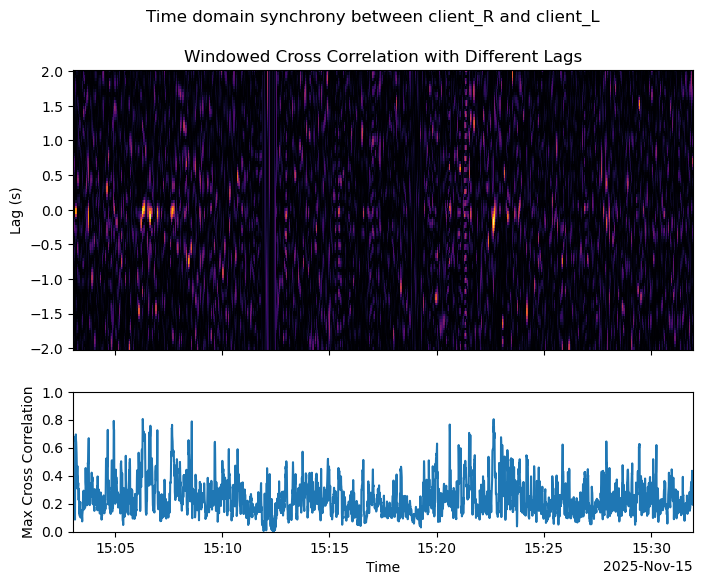

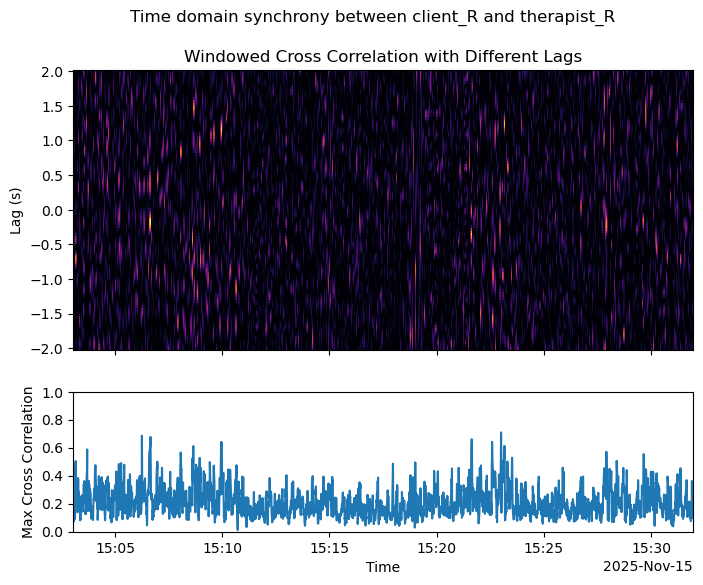

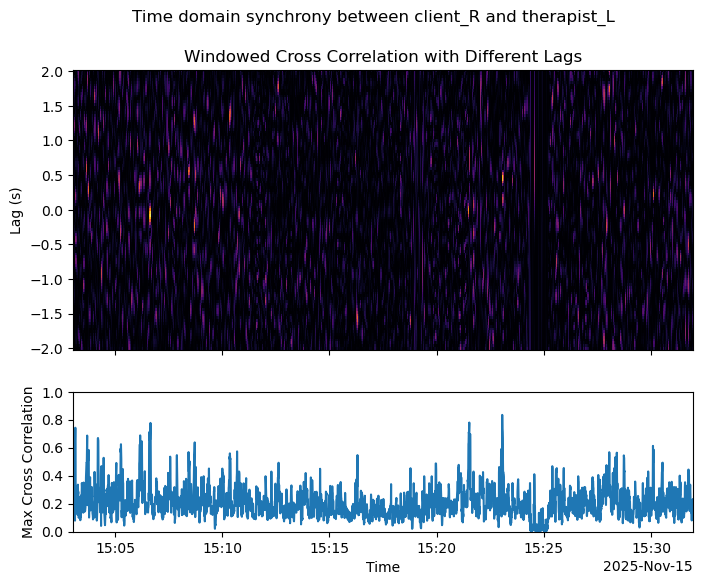

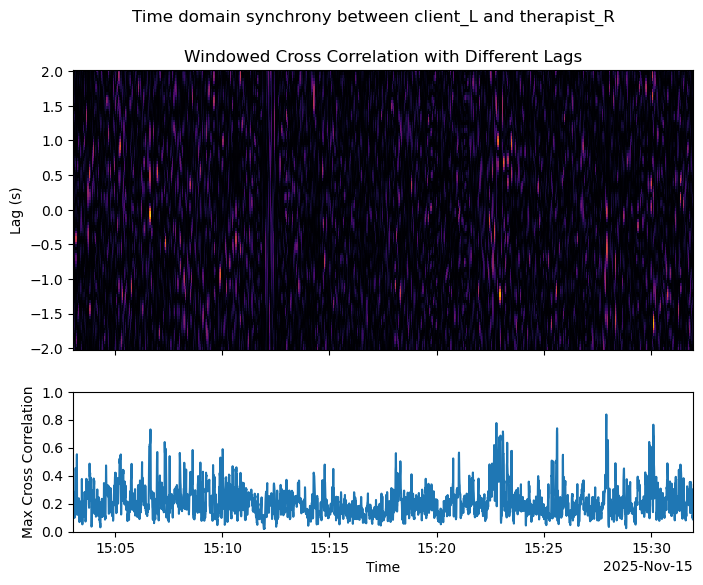

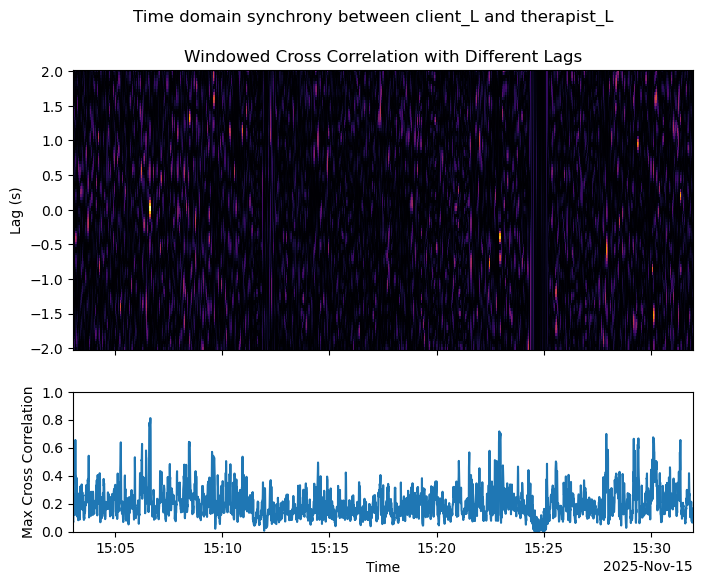

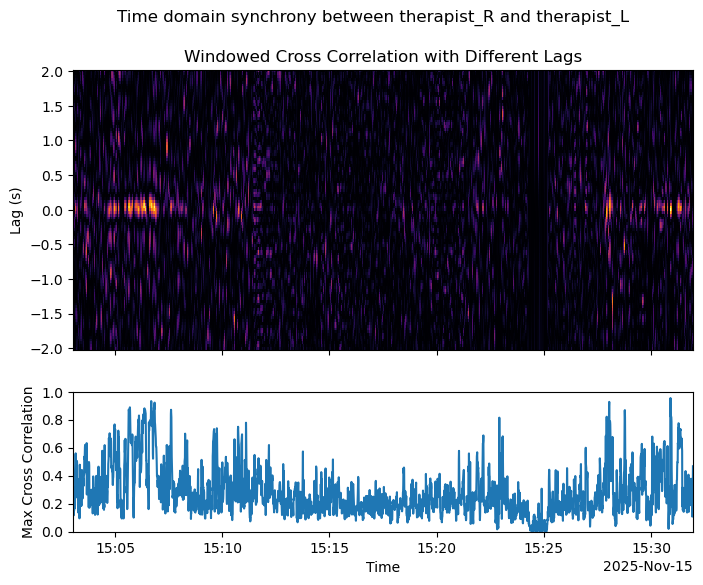

In [143]:
from itertools import combinations

# get all combinations (all keys choose 2)
# iterate through all combinations and plot tlcc based synchrony curve
for x, y in combinations(acc_mag.keys(), 2):
    tlcc = util.frame_xcorr(acc_mag[x], acc_mag[y])
    # Squaring to get correlation coefficient
    r_sq = (tlcc ** 2)

    fig = viz.plot_corr_df(r_sq)
    fig.suptitle(f"Time domain synchrony between {x} and {y}")
    plt.show()

# 3 Time-Frequency based synchrony analysis method: 
- using STFT as PoC for now, but literature suggests wavelet transform.
- Other Time-Frequency representations may include: CQT, HHT, etc.
- Besides coherence, other measures include: Phase Locking Value (PLV), Phase Lag Index (PLI), etc.

STFT parameters: n_fft=128, hop_length=12, win_length=128


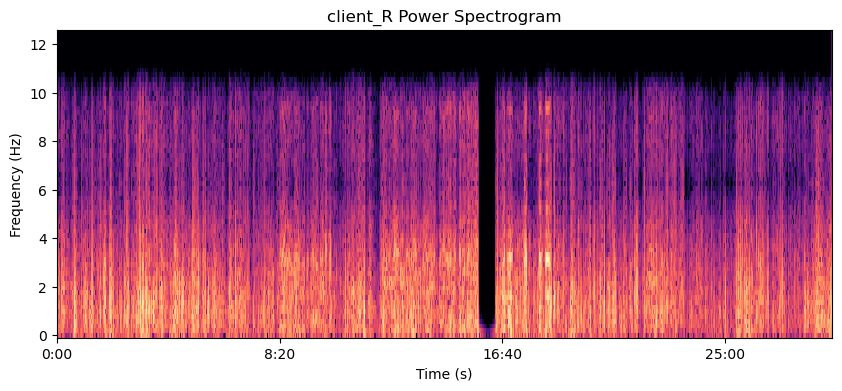

STFT parameters: n_fft=128, hop_length=12, win_length=128


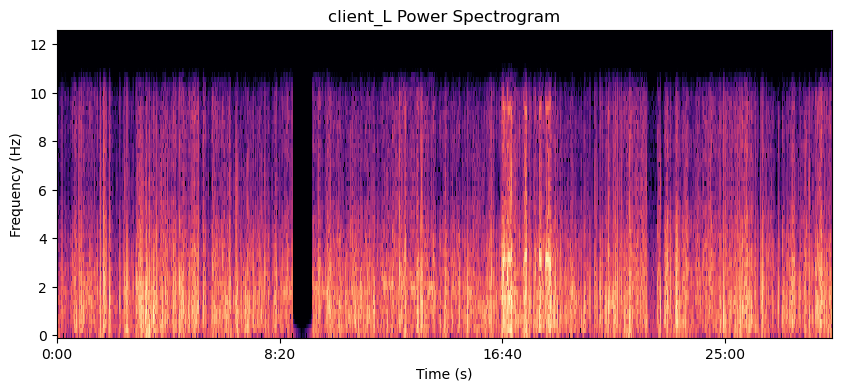

STFT parameters: n_fft=128, hop_length=12, win_length=128


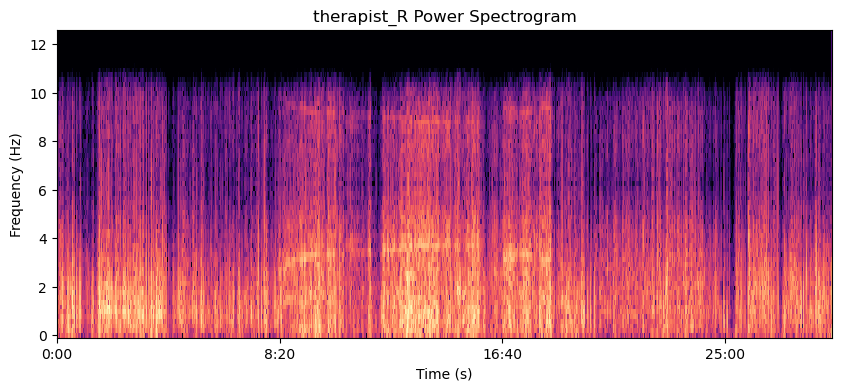

STFT parameters: n_fft=128, hop_length=12, win_length=128


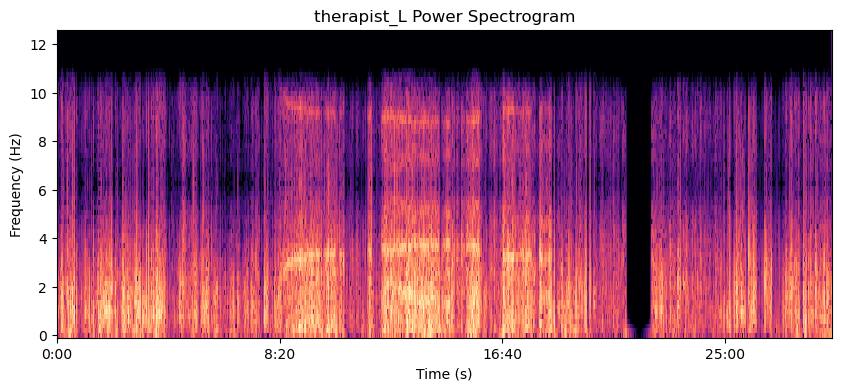

In [144]:
# Compute spectrograms for each session and visualize them
# The plot starts at 15:03:00.
for wearable in acc_mag:
    S = util.stft(acc_mag[wearable], win_length=5.12, hop=0.5, sr=25.0, verbose=True)
    viz.plot_spec(S, sr=25.0, hop_length=12, n_fft=128, figsize=(10, 4))
    plt.title(wearable + " Power Spectrogram")
    plt.show()

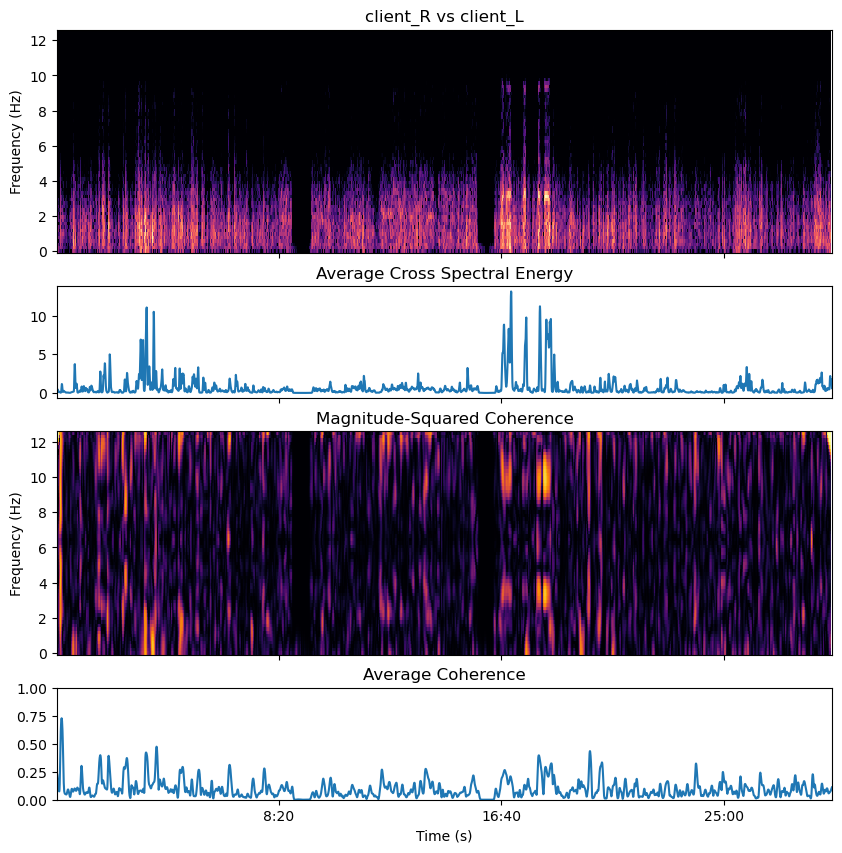

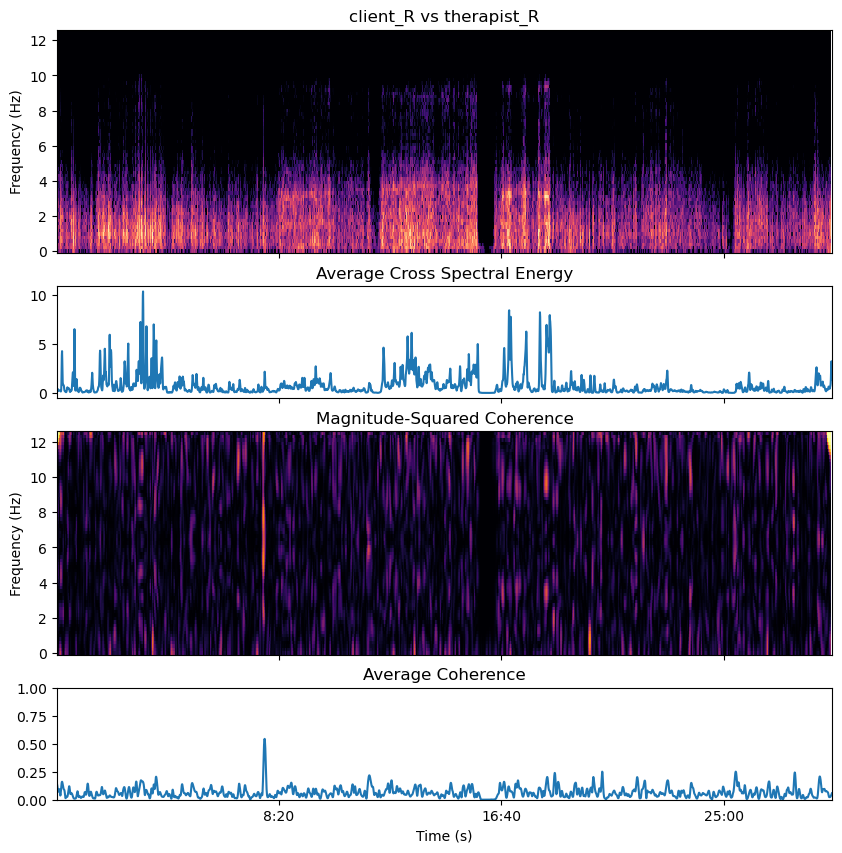

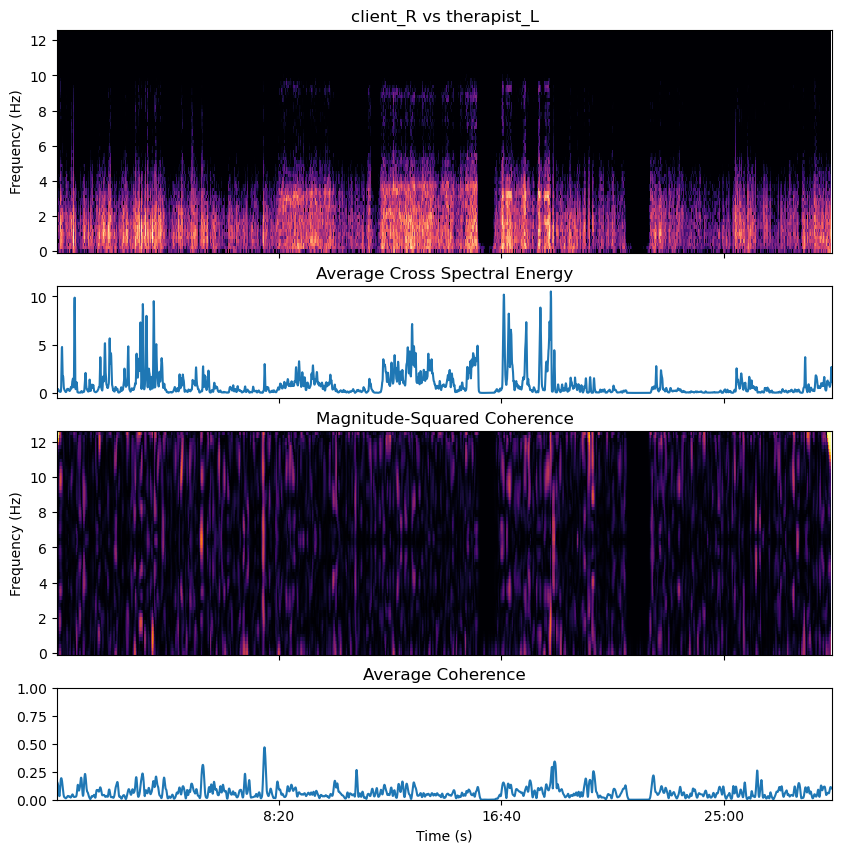

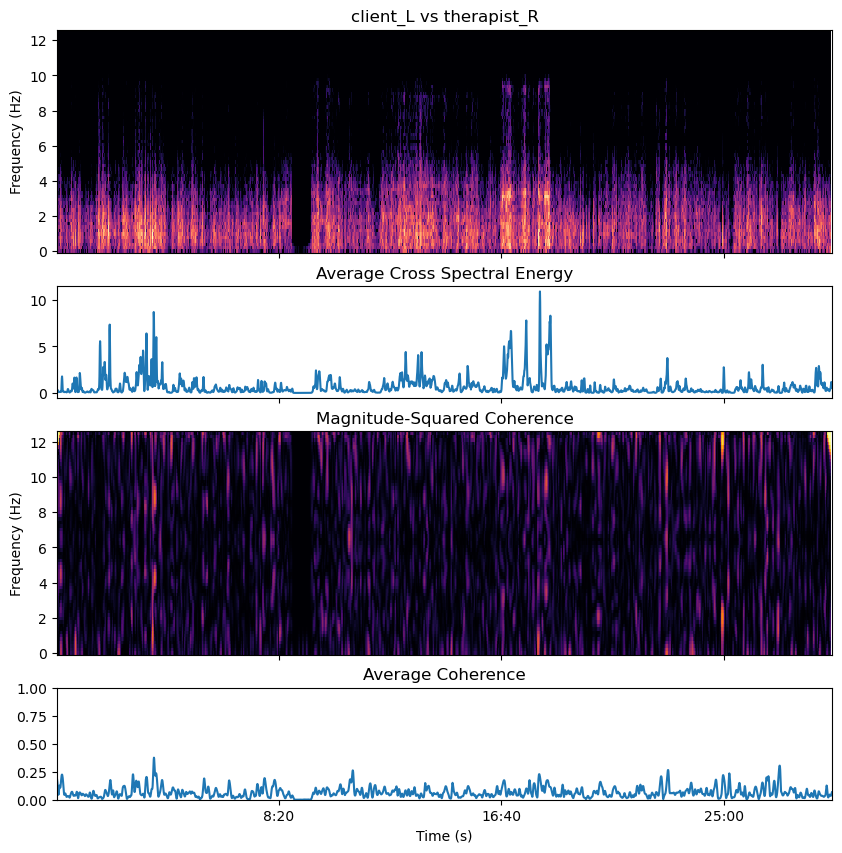

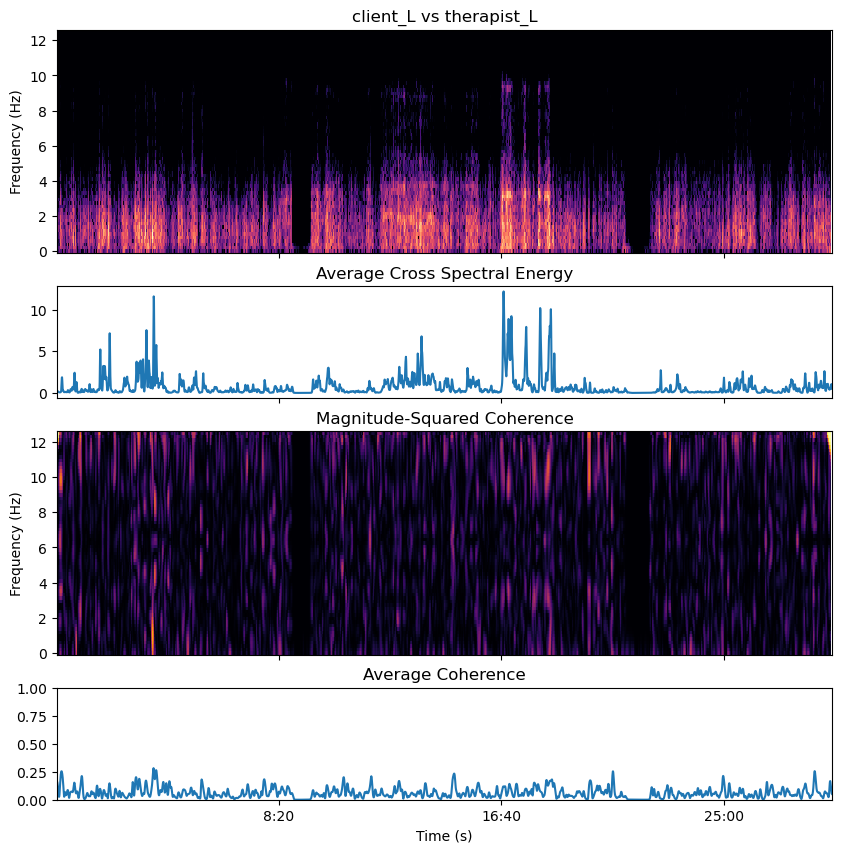

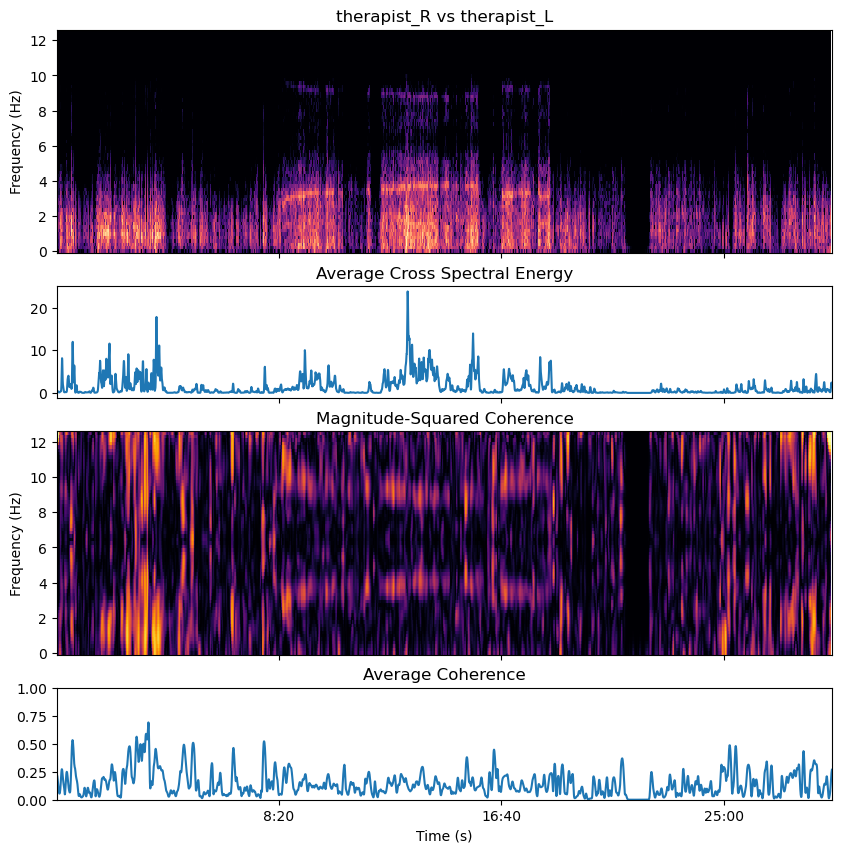

In [146]:
# Now let's visualize their cross spectrums S_i * S_j^*
for pair in combinations(acc_mag.keys(), 2):
    i, j = pair
    S_i = util.stft(acc_mag[i], win_length=5.12, hop=0.5, sr=25.0)
    S_j = util.stft(acc_mag[j], win_length=5.12, hop=0.5, sr=25.0)
    S_ij = S_i * S_j.conj()
    avg_energy = np.mean(np.abs(S_ij), axis=0) / 1e6

    # Compute coherence with physical smoothing
    # These parameters for smoothing has huge effects on the resulting coherence mat.
    # Investigation needed here for picking parameters and understanding their different behaviors.
    sigma_sec = 2  # 2s temporal smoothing
    sigma_hz = 0.5   # 0.5Hz spectral smoothing
    sr = 25.0
    n_fft = 128
    hop_length = 12
    
    sigma_f, sigma_t = util.physical_to_bin_sigmas(sigma_sec, sigma_hz, sr, n_fft, hop_length)
    
    coherence = util.spec_coherence(S_i, S_j, sigma=(sigma_f, sigma_t))
    avg_subband_coherence = np.mean(coherence[5:-20, :], axis=0)

    times = librosa.times_like(S_ij, sr=25.0, hop_length=12, n_fft=128)

    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True, height_ratios=[2,1,2,1])

    viz.plot_spec(S_ij, sr=25.0, hop_length=12, n_fft=128, ax=axes[0])
    axes[0].set_title(f"{i} vs {j}")
    axes[0].set_xlabel("")

    axes[1].plot(times, avg_energy)
    axes[1].set_title("Average Cross Spectral Energy")

    viz.plot_coherence(coherence, sr=25.0, hop_length=12, ax=axes[2])
    axes[2].set_title("Magnitude-Squared Coherence")
    axes[2].set_xlabel("")

    axes[3].plot(times, avg_subband_coherence)
    axes[3].set_title("Average Coherence")
    axes[3].set_xlabel("Time (s)")
    axes[3].set_ylim(0, 1)

    dt = 12 / 25.0
    axes[3].set_xlim(times[0] - dt / 2, times[-1] + dt / 2)

    plt.show()

# End of notebook